# CS 418 Final Project  
## Media Framing of Palestine  

**Group Name:** 404: Data Not Found  
**Group Members:**  Bryan Dominguez, Sami Fariz, Safe Nassan, Baraa Eldeirawi, Justin McClain

## Introduction 
This project analyzes how international media frames the Palestine-Israel conflict using news headline data. We examine differences in coverage across countries in terms of volume, timing, and wording patterns. Using NLP techniques such as TF-IDF and machine learning models, we aim to identify patterns in how different countries report on the conflict.

In [1]:
from IPython.display import display
from analysis_helpers import (load_and_clean_data,plot_country_counts,plot_monthly_counts,plot_topic_emphasis, plot_headline_length,prepare_ml,run_logistic_regression,run_naive_bayes,plot_model_accuracy,plot_f1_scores)
df_selected, df_ml, summary = load_and_clean_data(force_refetch=False)
display(summary)

,Metric,Value
0,Raw collected rows,1000
1,After duplicate removal,939
2,After dropping missing values,932
3,After valid date filtering,925
4,After headline-length filtering,877
5,Rows in selected dataset,589
6,Rows in ML dataset,204
7,Date range,2026-03-01 to 2026-04-30


## Data
We collected 853 news headlines using the GDELT API with keywords such as “Palestine,” “Gaza,” and “West Bank.” The dataset spans from February 1, 2026 to April 29, 2026 and includes sources from countries such as Turkey, Israel, the United States, and Egypt. Each record includes the headline text, country, and publication date.

## Data Cleaning
We cleaned the dataset by removing duplicate articles and filtering out missing values in key fields such as title, source country, and date. We converted dates into a standard datetime format and removed invalid entries. We also normalized the text by converting headlines to lowercase and removing symbols, creating a `clean_text` column for analysis. Additionally, we filtered out very short headlines to ensure meaningful content for analysis. This preprocessing ensured consistency and improved the quality of the dataset for both visualization and machine learning tasks.

## Exploratory Data Analysis
We performed exploratory data analysis to better understand the distribution of the dataset. The data is unevenly distributed across countries, with some sources contributing significantly more headlines than others. To focus our analysis, we selected the top countries with the highest number of articles. We also created a subset for machine learning by balancing the dataset across the top three countries to avoid bias in classification. Additionally, we examined temporal trends and headline characteristics, which showed that article volume fluctuates over time, likely corresponding to major events.

## Visualizations
We created visualizations to compare headline coverage across countries. These charts help show differences in coverage volume and topic emphasis.

**Visualization 1: Headline Counts by Country**

This chart shows that the selected dataset is unevenly distributed across countries. Turkey contributes the most Palestine-related headlines, while Israel, the United States, and Egypt contribute fewer.

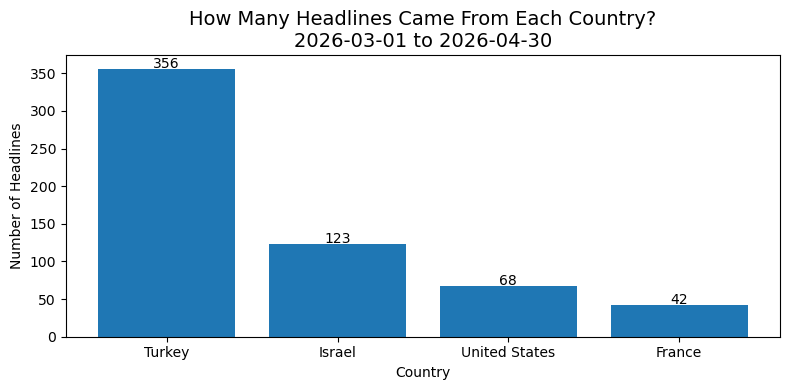

In [2]:
plot_country_counts(df_selected)

**Visualization 2: Monthly Coverage Trends**

This chart shows how Palestine-related headline volume changes over time by country. Coverage fluctuates across months, suggesting that media attention changes depending on timing and events.

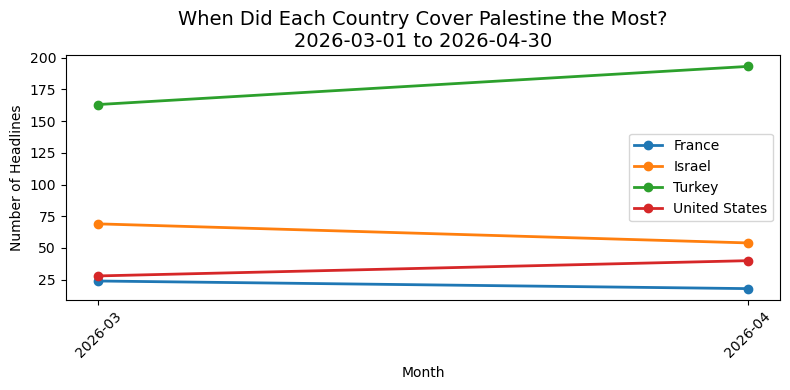

source_country,France,Israel,Turkey,United States
month,,,,
2026-03,24,69,163,28
2026-04,18,54,193,40


In [3]:
plot_monthly_counts(df_selected)

## Visualization 3: Average Headline Length by Country

This chart compares average headline length across source countries. It helps show whether countries differ not only in how much they cover Palestine-related topics, but also in how they structure their headlines.

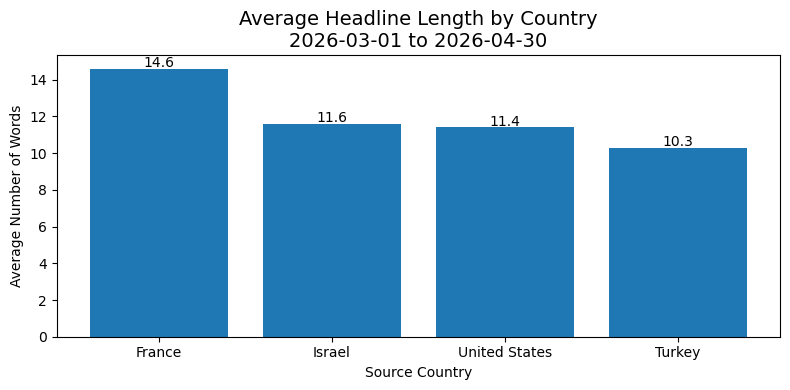

Kruskal-Wallis statistic: 40.1468
p-value: 0.0


In [4]:
kw_stat, kw_p = plot_headline_length(df_selected)
print("Kruskal-Wallis statistic:", kw_stat)
print("p-value:", kw_p)

**Statistical Analysis: Headline Length Differences**

We used a Kruskal-Wallis test to compare headline length distributions across countries. This helps evaluate whether countries differ not only in coverage volume and topic emphasis, but also in headline structure.

In [5]:
X_train_tfidf, X_test_tfidf, y_train, y_test = prepare_ml(df_ml)

Countries used for ML:
source_country
Turkey           68
Israel           68
United States    68
Name: count, dtype: int64
Training shape: (153, 2256)
Test shape: (51, 2256)


## Machine Learning

We converted and cleaned headline text into TF-IDF features and trained classification models to predict the source country. We used a balanced subset of the top countries so the model would not simply learn to favor the most common country.

In [6]:
X_train_tfidf, X_test_tfidf, y_train, y_test = prepare_ml(df_ml)

Countries used for ML:
source_country
Turkey           68
Israel           68
United States    68
Name: count, dtype: int64
Training shape: (153, 2256)
Test shape: (51, 2256)


**Logistic Regression Results**

The Logistic Regression model achieved an accuracy of approximately 0.73, significantly outperforming the baseline accuracy of 0.33. This indicates that the model is learning meaningful patterns from the headline text. The classification report shows strong performance across all countries, with high precision, recall, and F1-scores.

In [16]:
baseline_acc, log_acc, log_report, log_preds = run_logistic_regression(X_train_tfidf,X_test_tfidf,y_train,y_test)
display(log_report)

Baseline label: Israel
Baseline accuracy: 0.3333
Logistic Regression accuracy: 0.7059

Logistic Regression Accuracy Report:


,precision,recall,f1-score,support
Israel,0.889,0.471,0.615,17.000
Turkey,0.737,0.824,0.778,17.000
United States,0.609,0.824,0.700,17.000
accuracy,0.706,0.706,0.706,0.706
macro avg,0.745,0.706,0.698,51.000
weighted avg,0.745,0.706,0.698,51.000


**Naive Bayes Results and Model Comparison**

The Naive Bayes model achieved an accuracy of approximately 0.77, also outperforming the baseline but slightly below Logistic Regression. The comparison chart shows that both models significantly outperform the baseline, with Logistic Regression performing the best overall. This suggests that headline wording contains patterns that can distinguish between countries.

In [17]:
nb_acc, nb_report, comparison_df, nb_preds = run_naive_bayes(X_train_tfidf,X_test_tfidf,y_train, y_test,baseline_acc,log_acc)
display(nb_report)
display(comparison_df)

Naive Bayes accuracy: 0.7059

Naive Bayes Accuracy Report:


,precision,recall,f1-score,support
Israel,0.800,0.471,0.593,17.000
Turkey,0.933,0.824,0.875,17.000
United States,0.538,0.824,0.651,17.000
accuracy,0.706,0.706,0.706,0.706
macro avg,0.757,0.706,0.706,51.000
weighted avg,0.757,0.706,0.706,51.000


,Model,Accuracy
1,Logistic Regression,0.705882
2,Naive Bayes,0.705882
0,Baseline,0.333333


## Model Performance by Country

This chart shows the F1-score for each model across different countries. Both models perform best on Turkey and are weaker on Israel and the United States. Overall, the models are still able to distinguish between countries better than the baseline, which suggests that headline text contains source-country-specific wording patterns.

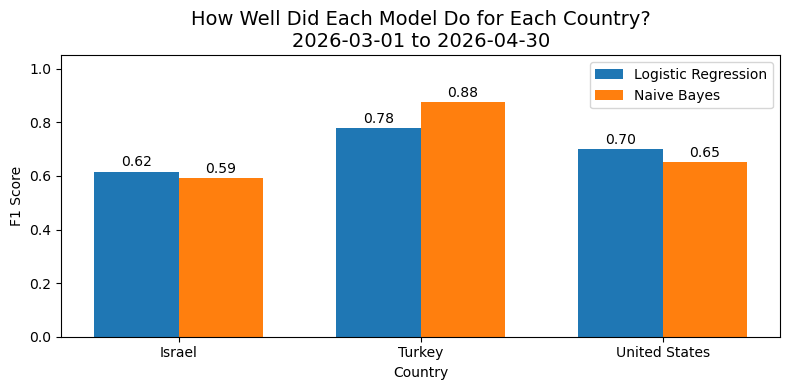

In [22]:
plot_f1_scores(y_test, log_preds, nb_preds, df_ml)

## Results

Our analysis shows that international media outlets frame Palestine-related news differently depending on the source country. Turkey consistently published the highest number of headlines, while Israel and the United States published fewer articles overall. Coverage volume also changed over time, suggesting that media attention increases during major conflict-related events.



## Future Work

For future work, we can expand this project by collecting a bigger dataset while filtering and balancing the data. We would also include a longer time range that included more countries and even languages. This would ensure that even older data would be included and would have more information.
